In [2]:
import numpy as np
import pandas as pd
import seaborn as sea 
import matplotlib.pyplot as plt
import phik

from sklearn.feature_selection import mutual_info_classif
from sklearn.model_selection import train_test_split, StratifiedKFold
from sklearn.metrics import average_precision_score
from sklearn.base import clone

import lightgbm, xgboost, catboost
from lightgbm import LGBMClassifier
from xgboost import XGBClassifier
from catboost import CatBoostClassifier

import optuna
import shap
import joblib
import warnings
warnings.filterwarnings("ignore")

---
# 1. Setting up Utility Functions

In [3]:
SEED = 3126

CAT_FEATURES = [
    'merchant_category','card_type', 'auth_method',
    'channel', 'device_type', 'day_of_week'
]

In [4]:
def engineer_features(X: pd.DataFrame) -> pd.DataFrame:
    X_copy = X.copy()
    X_copy["txn_count_last_24h"] = X_copy["txn_count_last_24h"].clip(upper=9)
    return X_copy


def convert_cat_features(X:pd.DataFrame, cat_features:list) -> pd.DataFrame:
    X_copy = X.copy()
    X_copy[cat_features] = X_copy[cat_features].astype("category")
    return X_copy


def process_features(X:pd.DataFrame, cat_features:list) -> pd.DataFrame:
    X_copy = engineer_features(X)
    X_copy = convert_cat_features(X_copy, cat_features)
    return X_copy

In [5]:
def make_train_test_sets(path:str, target_variable="is_fraud", test_size=0.3, random_state=3126):
    """
    Parameters:
        path (str): Path to the CSV file containing the dataset.
        target_variable (str): Name of the target column to predict. Default "is_fraud".
        test_size (float): Proportion of data to allocate to the test set. Default 0.3.
        random_state (int): Seed for reproducible splitting. Default 3126.
    Return:
        X_train, X_test, y_train, y_test: Stratified train/test split of features and target.
    """
    ## Reads data and splits into X and y 
    X  = pd.read_csv(path).drop(columns=["transaction_id"])
    y  = X.pop(target_variable)
    
    ## Splits intro train and test sets
    X_train, X_test, y_train, y_test = train_test_split(
      X, y, test_size=test_size, random_state=random_state, shuffle=True, stratify=y
    )
    ## Reset indices after splitting
    X_train = X_train.reset_index(drop=True)
    X_test  = X_test.reset_index(drop=True)
    y_train = y_train.reset_index(drop=True)
    y_test  = y_test.reset_index(drop=True)
    
    return X_train, X_test, y_train, y_test

In [6]:
def cross_validate(model, model_name, X, y, cat_features, save_model_path, scorer=average_precision_score, n_splits=5, random_state=3126):
    """
    Params:
        model: unfitted sklearn-compatible estimator to clone and fit each fold.
        model_name: one of "lgbm", "xgb", "catboost", or other (plain .fit()).
        X: feature matrix.
        y: target vector, index-aligned with X.
        save_model_path: directory to dump fold models to; skipped if None.
        scorer: metric function scorer(y_true, y_pred) -> float.
        n_splits: number of StratifiedKFold splits. Default 5.
        random_state: seed for fold shuffling. Default 3126.

    Return:
        dict: {
            "scores": array of per-fold metric values,
            "OOF": out-of-fold predictions,
            "fold_number": fold id per sample
        }
    """

    skf = StratifiedKFold(n_splits=n_splits, random_state=random_state, shuffle=True)
    history = {
        "scores": np.zeros(n_splits),
        "OOF": np.zeros(len(y)),
        "fold_number": np.zeros(len(y))
    }

    for k,(train_idx,val_idx) in enumerate(skf.split(X, y)):
        X_t, y_t = X.iloc[train_idx,:], y[train_idx]
        X_v, y_v = X.iloc[val_idx,:],   y[val_idx]

        ## Process features
        X_t = process_features(X_t, cat_features)
        X_v = process_features(X_v, cat_features)
        
        # Fits appropriate cloned model
        cloned_model = clone(model)

        if model_name == "lgbm":
            cloned_model.fit(
                X_t, y_t,
                eval_set=[(X_v, y_v)], eval_metric='average_precision',
                callbacks=[lightgbm.early_stopping(100, verbose=False)])

        elif model_name == "xgb":
            cloned_model.fit(
                X_t, y_t, 
                eval_set=[(X_v, y_v)], verbose=False)

        elif model_name == "catboost":
            cloned_model.fit(
                X_t, y_t,
                eval_set=(X_v, y_v), cat_features=cat_features,
                early_stopping_rounds=100, verbose=False)

        else: cloned_model.fit(X_t, y_t)

        # Make predictions and store results
        y_preds = cloned_model.predict_proba(X_v)[:, -1]
        
        history["OOF"][val_idx] = y_preds
        history["fold_number"][val_idx] = k + 1
        history["scores"][k] = scorer(y_v, y_preds)

        # Saves model if needed
        if save_model_path is not None:
            joblib.dump(cloned_model, f"{save_model_path}/{model_name}_{k + 1}.joblib")
    return history

In [7]:
def test_model(model, model_name, X_test, y_test, scorer=average_precision_score):
    """
    Evaluate a trained classifier on a test set using probability-based scoring
    and print the result.

    Params:
        model (estimator): Trained classifier with a `predict_proba` method.
        model_name (str): Name of the model, used for the printed output.
        X_test: Test set features.
        y_test: True labels for the test set.
        scorer (callable): Scoring function with signature `scorer(y_true, y_score)`

    Return:
        None. Prints the computed score.
    """
    y_preds = model.predict_proba(X_test)[:, -1]
    score   = scorer(y_test, y_preds)
    print(f"Average Precision of {model_name} on Test Set: {score:.3f}")

---
# 2. Optuna Optimization

In [8]:
file_path = "/kaggle/input/datasets/uditjain13/credit-card-fraud-detection-2026/credit_card_fraud_2026.csv"
X_train, X_test, y_train, y_test = make_train_test_sets(file_path)

In [9]:
# def objective(trial):
#     params = {
#         ## Tree-based items
#         "max_depth":trial.suggest_int("max_depth", 2, 10),
#         "learning_rate":trial.suggest_float("learning_rate", .05, .5, log=True),
#         "min_child_samples":trial.suggest_int("min_child_samples", 10, 200),
#         ## Column and row sampling
#         "colsample_bytree":trial.suggest_float("colsample_bytree", .5, 1.0),
#         "subsample_freq":trial.suggest_int("subsample_freq", 1, 10),
#         "subsample":trial.suggest_float("subsample", .5, 1.0),
#         ## Regularizations
#         "reg_alpha":trial.suggest_float("reg_alpha", 1e-4, 1e-1, log=True),
#         "reg_lambda":trial.suggest_float("reg_lambda", 1e-4, 1e-1, log=True)
#     }
#     params["num_leaves"] = trial.suggest_int("num_leaves", 4, 2**params["max_depth"])
#     params["n_estimators"] = 3000
#     params["random_state"] = SEED
#     params["metric"]  = "average_precision"
#     params["verbose"] = -1
#     params["n_jobs"]  = -1
    
#     model  = LGBMClassifier(**params)
#     OOF_scores = []
#     for k in range(1,6):
#         history = cross_validate(model, "lgbm", X_train, y_train, CAT_FEATURES, None, random_state=SEED+k)
#         OOF_scores.append(average_precision_score(y_train, history["OOF"]))
#     return np.mean(OOF_scores)


# study = optuna.create_study(
#     direction="maximize",
#     sampler=optuna.samplers.TPESampler(seed=SEED)
# )
# study.optimize(objective, n_trials=100)  

In [10]:
params = {
    'max_depth': 2,
    'learning_rate': 0.08349675584785622,
    'min_child_samples': 157,
    'colsample_bytree': 0.566103776744134,
    'subsample_freq': 1,
    'subsample': 0.746454129498097,
    'reg_alpha': 0.0761330323524693,
    'reg_lambda': 0.021754123234282757,
    'num_leaves': 4
}
params["n_estimators"] = 3000
params["random_state"] = SEED
params["metric"]  = "average_precision"
params["verbose"] = -1
params["n_jobs"]  = -1

model   = LGBMClassifier(**params)
history = cross_validate(model, "lgbm", X_train, y_train, CAT_FEATURES, "/kaggle/working")

print(f"Average-Precision Scores Across Folds: {np.round(history["scores"], 3)}")
print(f"Mean Average-Precision Score Across Folds: {np.mean(history["scores"]):.3f}")
print(f"Overall OOF Average-Precision Score: {average_precision_score(y_train, history["OOF"]):.3f}")
print()

for k in range(1,6):
    model = joblib.load(f"/kaggle/working/lgbm_{k}.joblib")
    print(f"LGBM Model {k} Best n_estimators: {model.best_iteration_}")

Average-Precision Scores Across Folds: [0.374 0.444 0.38  0.409 0.535]
Mean Average-Precision Score Across Folds: 0.428
Overall OOF Average-Precision Score: 0.415

LGBM Model 1 Best n_estimators: 142
LGBM Model 2 Best n_estimators: 86
LGBM Model 3 Best n_estimators: 109
LGBM Model 4 Best n_estimators: 165
LGBM Model 5 Best n_estimators: 251


In [12]:
n_estimators_range = np.arange(80, 151)
ap_scores = []
candidate_params = params.copy()


for n_estimators_candidate in n_estimators_range:
    candidate_params["n_estimators"] = n_estimators_candidate
    model   = LGBMClassifier(**candidate_params)
    skf     = StratifiedKFold(n_splits=5, random_state=SEED, shuffle=True)
    y_oof   = np.zeros(len(y_train))
    
    for k,(train_idx,val_idx) in enumerate(skf.split(X_train, y_train)):
        ## Splits training/validation data
        X_t, y_t = X_train.iloc[train_idx,:], y_train[train_idx]
        X_v, y_v = X_train.iloc[val_idx,:],   y_train[val_idx]
        ## Process features
        X_t = process_features(X_t, CAT_FEATURES)
        X_v = process_features(X_v, CAT_FEATURES)
        # Fits cloned model
        cloned_model = clone(model)
        cloned_model.fit(X_t, y_t)
        ## Stores OOF prediction
        y_oof[val_idx] = cloned_model.predict_proba(X_v)[:, -1]
    ## Stores overall score
    ap_scores.append(average_precision_score(y_train, y_oof))

print(f"Best n_estimators value: {n_estimators_range[np.argmax(ap_scores)]}")
print(f"Best Overal OOF Average-Precision Score: {ap_scores[np.argmax(ap_scores)]:.3f}")

Best n_estimators value: 139
Best Overal OOF Average-Precision Score: 0.417


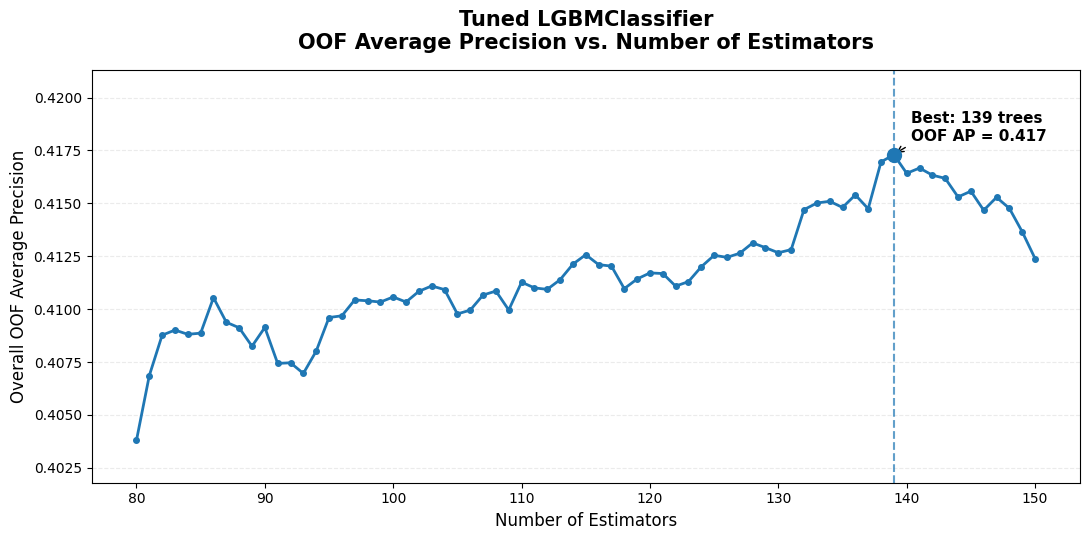

In [23]:
plt.figure(figsize=(11, 5.5))

plt.plot(
    n_estimators_range,
    ap_scores,
    marker="o",
    markersize=4,
    linewidth=2
)

# Highlight optimum
plt.scatter(
    best_n,
    best_ap,
    s=100,
    zorder=5
)

plt.axvline(
    best_n,
    linestyle="--",
    linewidth=1.5,
    alpha=0.7
)

plt.annotate(
    f"Best: {best_n} trees\nOOF AP = {best_ap:.3f}",
    xy=(best_n, best_ap),
    xytext=(12, 10),
    textcoords="offset points",
    fontsize=11,
    fontweight="bold",
    arrowprops=dict(
        arrowstyle="->",
        connectionstyle="arc3,rad=0.15"
    )
)

plt.title(
    "Tuned LGBMClassifier\nOOF Average Precision vs. Number of Estimators",
    fontsize=15,
    fontweight="bold",
    pad=15
)

plt.xlabel("Number of Estimators", fontsize=12)
plt.ylabel("Overall OOF Average Precision", fontsize=12)

# Show only every 10th estimator
plt.xticks(np.arange(80, 151, 10))

plt.ylim(
    min(ap_scores) - 0.002,
    max(ap_scores) + 0.004
)

plt.grid(
    axis="y",
    linestyle="--",
    alpha=0.25
)

plt.tick_params(
    axis="both",
    labelsize=10
)

plt.tight_layout()
plt.show()

In [14]:
lgbm_params = {
    'max_depth': 2,
    'learning_rate': 0.08349675584785622,
    'min_child_samples': 157,
    'colsample_bytree': 0.566103776744134,
    'subsample_freq': 1,
    'subsample': 0.746454129498097,
    'reg_alpha': 0.0761330323524693,
    'reg_lambda': 0.021754123234282757,
    'num_leaves': 4,

    'n_estimators':139,
    'random_state':SEED,
    'metric':'average_precision',,
    'verbose':-1,
    'n_jobs':-1
}

X_tr = process_features(X_train, CAT_FEATURES)
X_t  = process_features(X_test, CAT_FEATURES)

lgbm_mod = LGBMClassifier(**lgbm_params)
lgbm_mod.fit(X_tr, y_train)

test_model(lgbm_mod, "Tuned LGBMClassifier", X_t, y_test)

Average Precision of Tuned LGBMClassifier on Test Set: 0.333


---
# Feature Importance Analysis

## Gain Importance

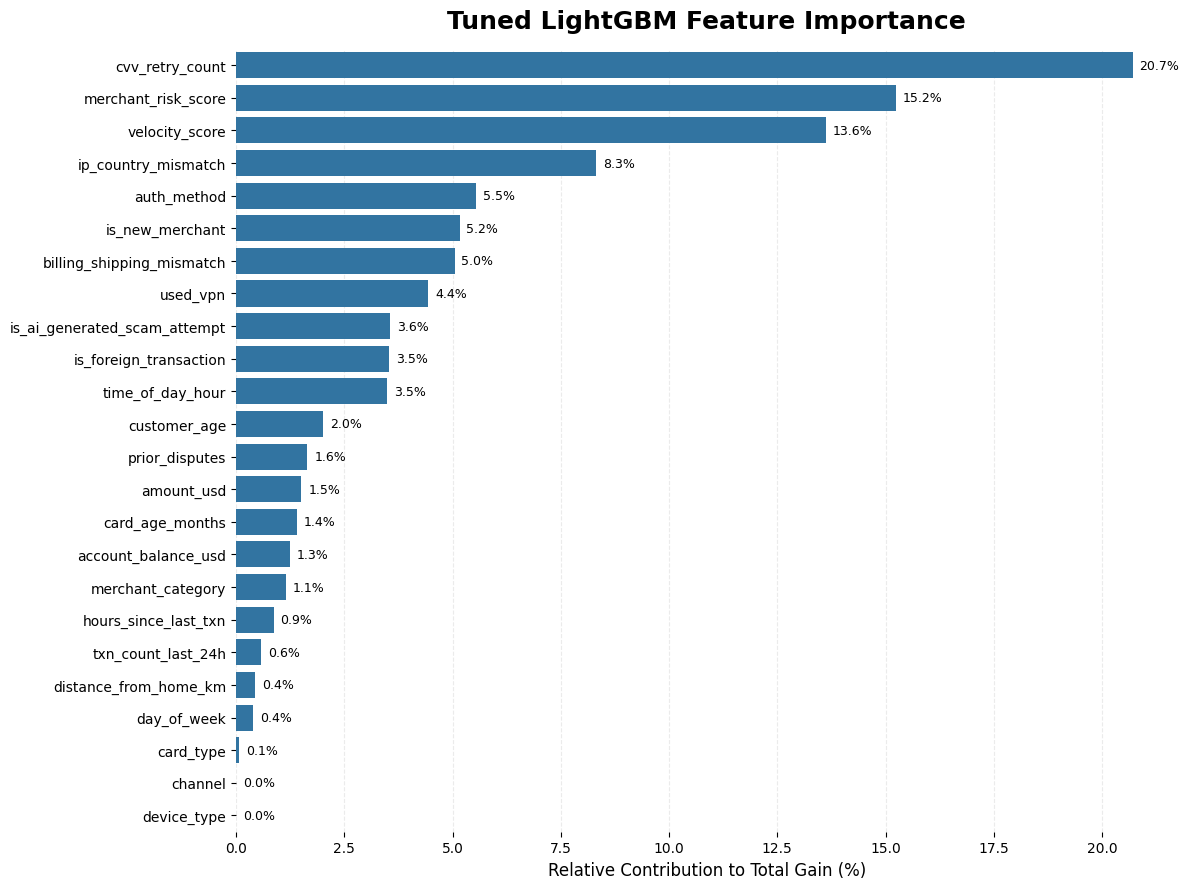

In [17]:
importance_df = pd.DataFrame({
    'feature': X_train.columns,
    'gain_importance':lgbm_mod.booster_.feature_importance(importance_type='gain')
})
importance_df["gain_pct"] = 100 * importance_df["gain_importance"]/importance_df["gain_importance"].sum()
plot_df = importance_df.sort_values("gain_pct", ascending=False)


plt.figure(figsize=(12, 9))
ax = sea.barplot(data=plot_df, x="gain_pct", y="feature", orient="h")

ax.set_title("Tuned LightGBM Feature Importance", fontsize=18, fontweight="bold", pad=15)
ax.set_xlabel("Relative Contribution to Total Gain (%)", fontsize=12)
ax.set_ylabel("")
sea.despine(left=True, bottom=True)
ax.grid(axis="x", linestyle="--", alpha=0.25)
ax.set_axisbelow(True)

for container in ax.containers:
    ax.bar_label(container,fmt="%.1f%%",padding=5,fontsize=9)

plt.tight_layout()
plt.show()

## SHAP Importance

In [18]:
X_tr, X_v, y_tr, y_v = train_test_split(
      X_train, y_train, test_size=.3, random_state=SEED, shuffle=True, stratify=y_train
)

X_tr = X_tr.reset_index(drop=True)
X_v  = X_v.reset_index(drop=True)
y_tr = y_tr.reset_index(drop=True)
y_v  = y_v.reset_index(drop=True)

lgbm_ = LGBMClassifier(**lgbm_params)
X_tr = process_features(X_tr, CAT_FEATURES)
X_v  = process_features(X_v, CAT_FEATURES)

lgbm_.fit(X_tr, y_tr)
print(f"Evaluator LGBM Model's Overall AP Score: {average_precision_score(y_v, lgbm_.predict_proba(X_v)[:,-1]):.3f}")

Evaluator LGBM Model's Overall AP Score: 0.349


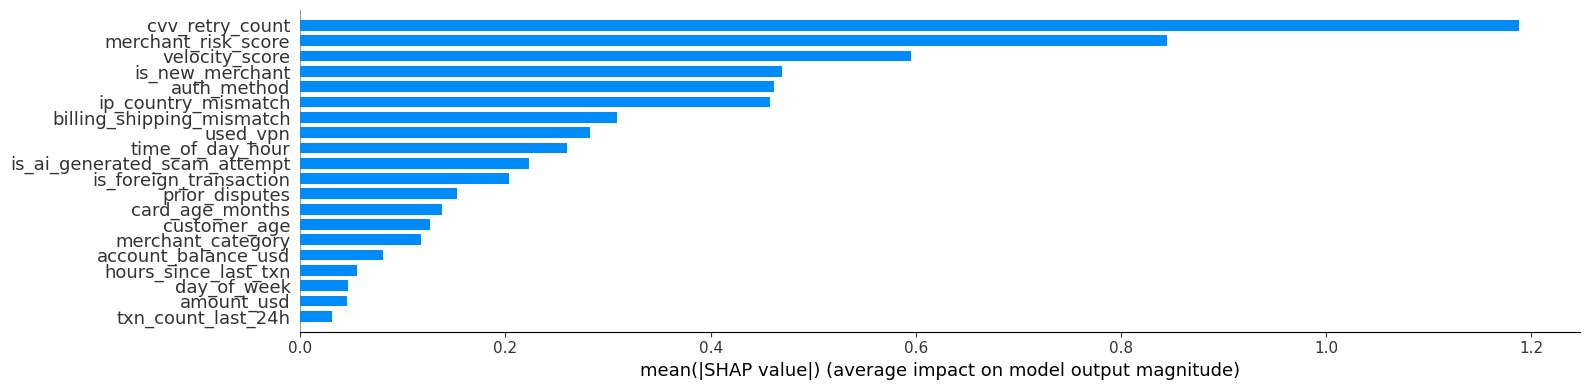

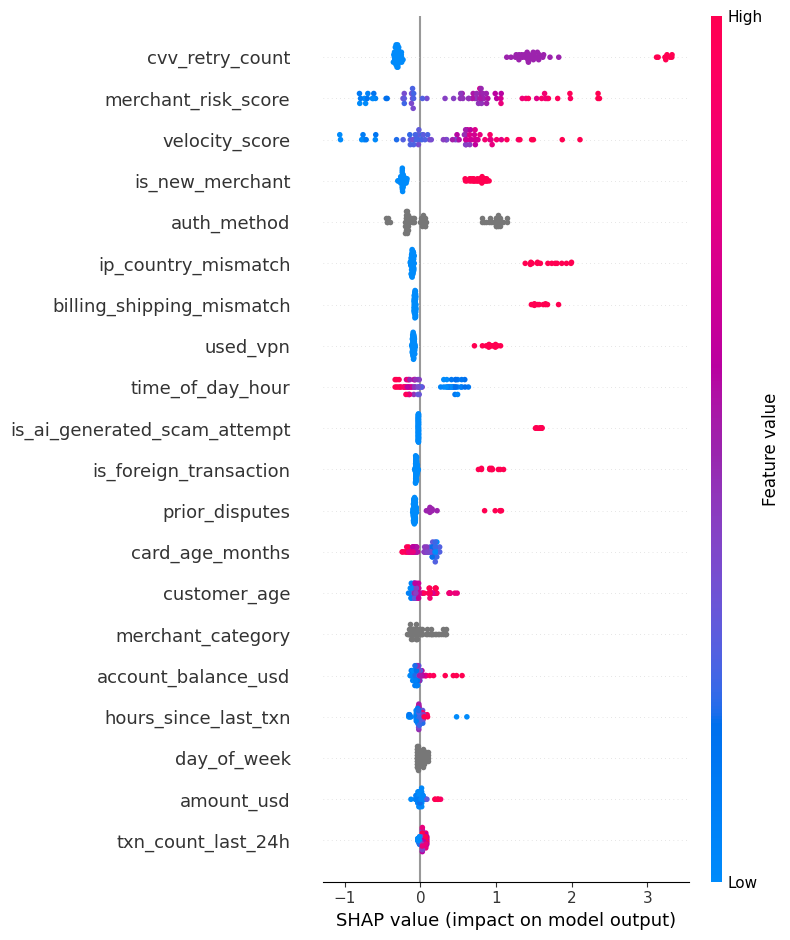

In [19]:
explainer   = shap.TreeExplainer(lgbm_)
shap_values = explainer.shap_values(X_v)
mask = y_v==1

shap.summary_plot(shap_values[mask], X_v.loc[mask], plot_type="bar", plot_size=(16,4))
shap.summary_plot(shap_values[mask], X_v.loc[mask])

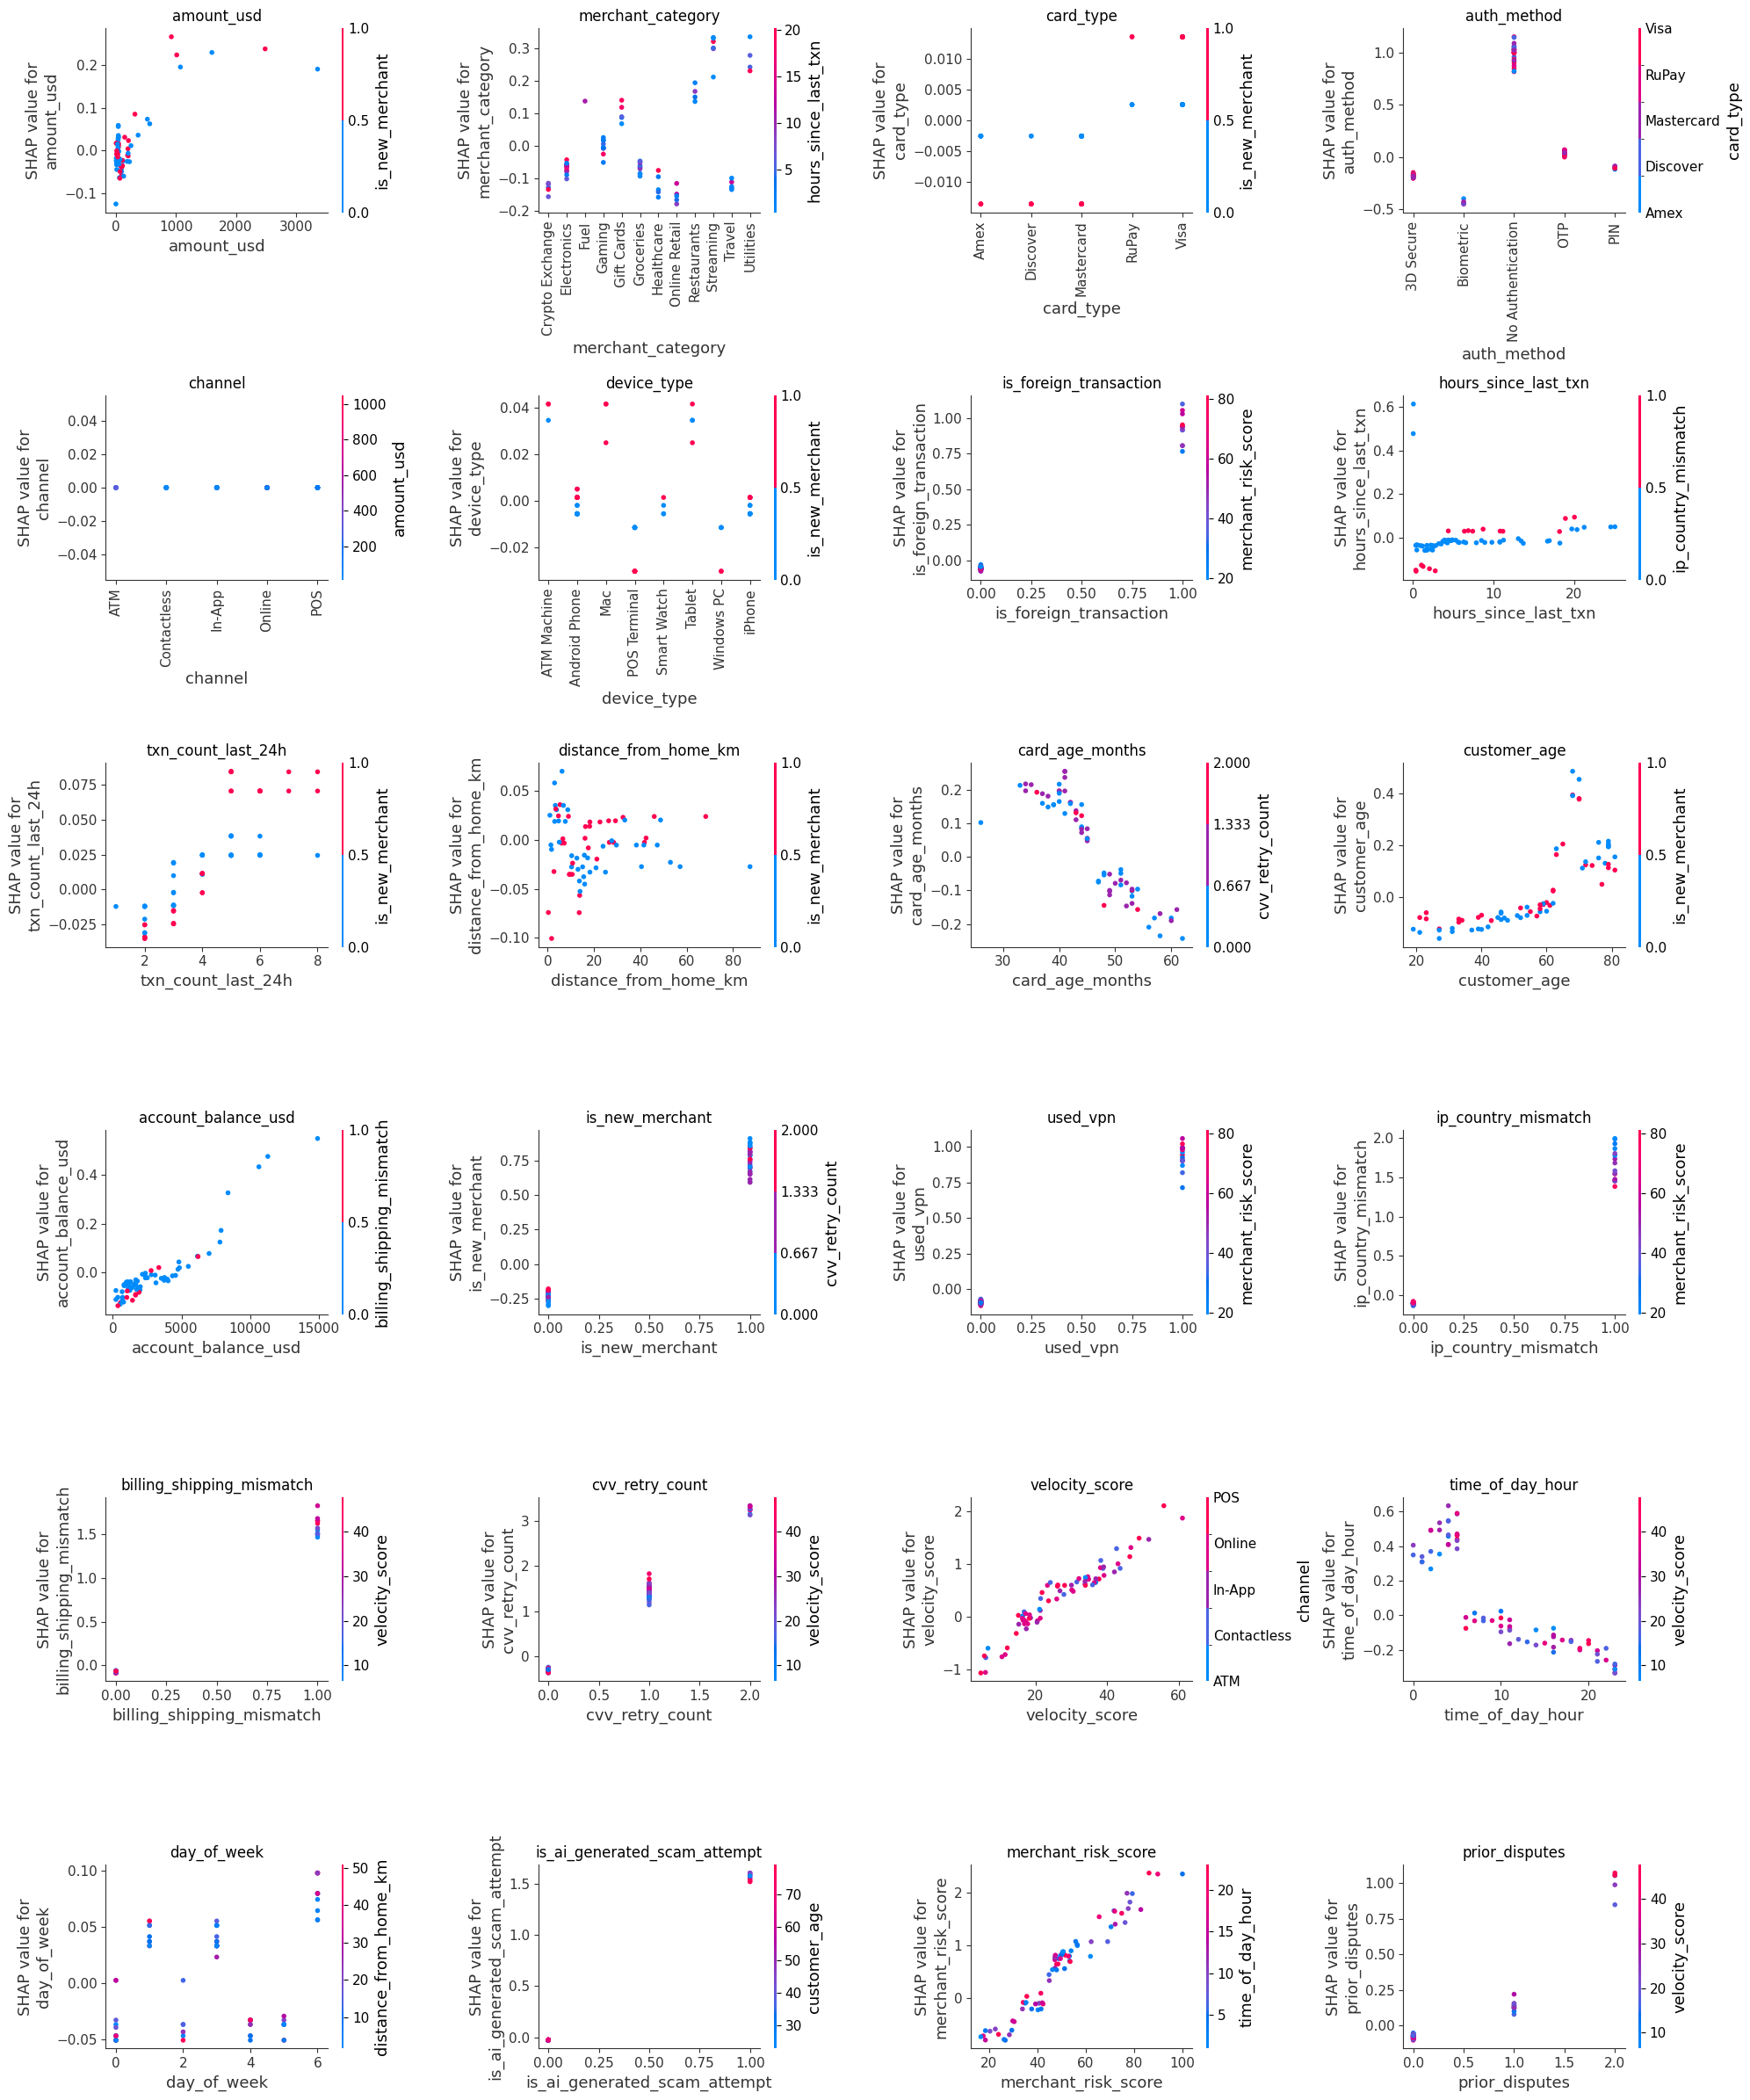

In [30]:
fig, axes = plt.subplots(6, 4, figsize=(20, 24))
axes = axes.flatten()

for ax, feature in zip(axes, X_v.columns):
    shap.dependence_plot(
        feature,
        shap_values[mask],
        X_v.loc[mask],
        ax=ax,
        show=False
    )
    ax.set_title(feature)

plt.tight_layout()
plt.show()